In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
import torch.nn as nn
import torchmetrics

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=toTensor
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=toTensor
)

In [2]:
training_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [3]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


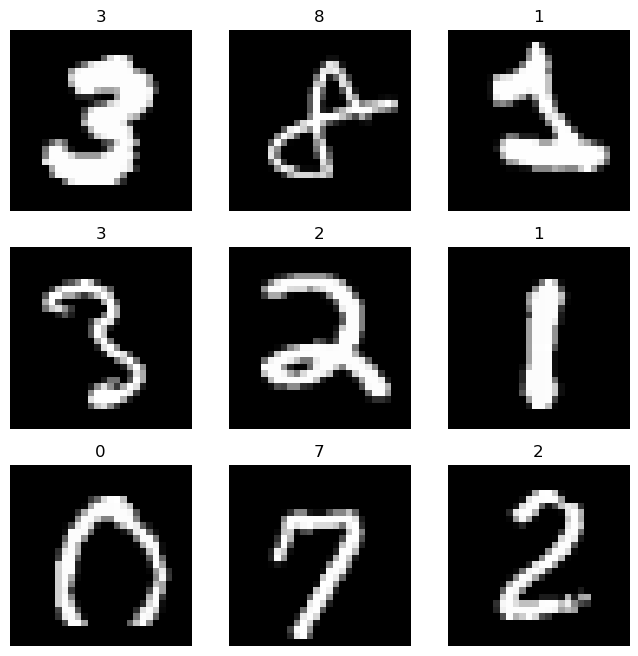

In [5]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Splitting into training, validation, and testing sets: 

In [6]:
torch.manual_seed(25)
train_data, valid_data = torch.utils.data.random_split(training_data, [50_000, 10_000])

In [7]:
torch.manual_seed(25)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [8]:
X_sample, y_sample = train_data[0]
print(X_sample.shape)
print(training_data.classes[y_sample])
print(training_data.classes)

torch.Size([1, 28, 28])
1 - one
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [9]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

In [10]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": [], "valid_losses" : []}
    for epoch in range(n_epochs):
        total_loss = 0.
        total_vloss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        for Xv_batch, yv_batch in valid_loader:
            Xv_batch, yv_batch = Xv_batch.to(device), yv_batch.to(device)
            
            yv_pred = model(Xv_batch)
            vloss = criterion(yv_pred, yv_batch)
            total_vloss += vloss.item()

        mean_loss = total_loss / len(train_loader)
        mean_vloss = total_vloss / len(valid_loader)
        history["train_losses"].append(mean_loss)
        history["valid_losses"].append(mean_vloss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [11]:
class ImageClassifier(nn.Module):
  def __init__(self, n_inputs, hidden_layers, n_classes):
    super().__init__()
    self.layers = nn.ModuleList()
    self.flatten = nn.Flatten()

    current_dim = n_inputs
    for h_dim in hidden_layers:
      self.layers.append(nn.Linear(current_dim, h_dim))
      self.layers.append(nn.ReLU())
      current_dim = h_dim

    self.output_layer = nn.Linear(current_dim, n_classes)
    self.layers.append(self.output_layer)
    print(self.layers)
    

  def forward(self, X):
    X = self.flatten(X)
    for layer in self.layers:
      X = layer(X)
    return X


torch.manual_seed(42)
# hidden_layers = [h1_dim, h2_dim, ..., hn_dim]
model = ImageClassifier(n_inputs=1*28*28, hidden_layers=[64,32], n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

ModuleList(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)


In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs= 10
history = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/10, train loss: 0.4959, train metric: 0.8623, valid metric: 0.9147
Epoch 2/10, train loss: 0.2409, train metric: 0.9310, valid metric: 0.9413
Epoch 3/10, train loss: 0.1794, train metric: 0.9480, valid metric: 0.9505
Epoch 4/10, train loss: 0.1442, train metric: 0.9577, valid metric: 0.9562
Epoch 5/10, train loss: 0.1196, train metric: 0.9647, valid metric: 0.9584
Epoch 6/10, train loss: 0.1011, train metric: 0.9700, valid metric: 0.9624
Epoch 7/10, train loss: 0.0875, train metric: 0.9740, valid metric: 0.9662
Epoch 8/10, train loss: 0.0760, train metric: 0.9773, valid metric: 0.9656
Epoch 9/10, train loss: 0.0672, train metric: 0.9798, valid metric: 0.9669
Epoch 10/10, train loss: 0.0590, train metric: 0.9823, valid metric: 0.9689


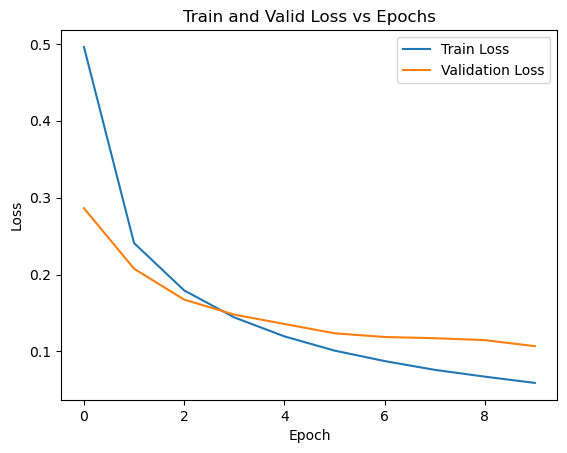

In [13]:
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['valid_losses'], label='Validation Loss')
plt.title('Train and Valid Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

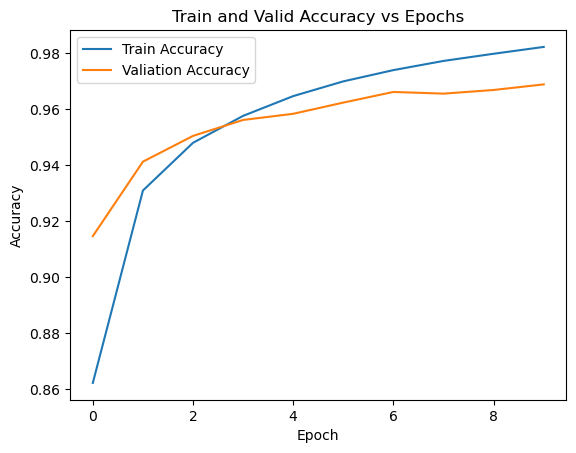

In [14]:
plt.plot(history['train_metrics'], label='Train Accuracy')
plt.plot(history['valid_metrics'], label='Valiation Accuracy')
plt.title('Train and Valid Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [15]:
print("test metric: ", evaluate_tm(model, test_loader, accuracy).item())

test metric:  0.9711999893188477


Might be starting to overfit to training data, but the train-test-validation accuracies are all relatively good.

### 3) Now modifying the architecture by adding more layers:

In [16]:
torch.manual_seed(42)
# hidden_layers = [h1_dim, h2_dim, ..., hn_dim]
model = ImageClassifier(n_inputs=1*28*28, hidden_layers=[256,128,64,32], n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

ModuleList(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=10, bias=True)
)


In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs= 10
history = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/10, train loss: 0.4428, train metric: 0.8637, valid metric: 0.9349
Epoch 2/10, train loss: 0.1650, train metric: 0.9513, valid metric: 0.9591
Epoch 3/10, train loss: 0.1097, train metric: 0.9673, valid metric: 0.9655
Epoch 4/10, train loss: 0.0799, train metric: 0.9752, valid metric: 0.9689
Epoch 5/10, train loss: 0.0609, train metric: 0.9810, valid metric: 0.9718
Epoch 6/10, train loss: 0.0470, train metric: 0.9855, valid metric: 0.9715
Epoch 7/10, train loss: 0.0357, train metric: 0.9886, valid metric: 0.9736
Epoch 8/10, train loss: 0.0305, train metric: 0.9902, valid metric: 0.9740
Epoch 9/10, train loss: 0.0262, train metric: 0.9915, valid metric: 0.9736
Epoch 10/10, train loss: 0.0222, train metric: 0.9929, valid metric: 0.9764


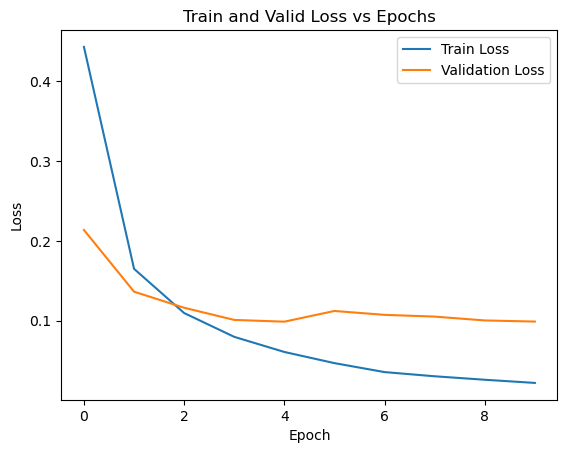

In [18]:
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['valid_losses'], label='Validation Loss')
plt.title('Train and Valid Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

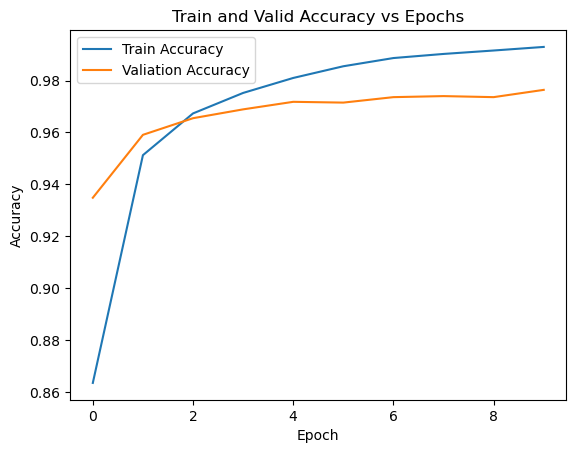

In [19]:
plt.plot(history['train_metrics'], label='Train Accuracy')
plt.plot(history['valid_metrics'], label='Valiation Accuracy')
plt.title('Train and Valid Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [20]:
print("test metric: ", evaluate_tm(model, test_loader, accuracy).item())

test metric:  0.9786999821662903


While all train-test-validation accuracies improved marginally, it seems to have exacerbated the overfitting slightly, which looks more prominent here in this model. This  could be due to the model being more complex and being able to better capture training data patterns.

### A4) Apply a learning rate scheduling strategy during training. Does it improve the model performance? Provide analysis based on your results.

In [27]:
def train3(model, optimizer, criterion, metric, train_loader, valid_loader, scheduler,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": [], "valid_losses" : []}
    for epoch in range(n_epochs):
        total_loss = 0.
        total_vloss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        for Xv_batch, yv_batch in valid_loader:
            Xv_batch, yv_batch = Xv_batch.to(device), yv_batch.to(device)
            
            yv_pred = model(Xv_batch)
            vloss = criterion(yv_pred, yv_batch)
            total_vloss += vloss.item()

        mean_loss = total_loss / len(train_loader)
        mean_vloss = total_vloss / len(valid_loader)
        history["train_losses"].append(mean_loss)
        history["valid_losses"].append(mean_vloss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        scheduler.step()
    return history

In [ ]:
torch.manual_seed(42)
# hidden_layers = [h1_dim, h2_dim, ..., hn_dim]
model = ImageClassifier(n_inputs=1*28*28, hidden_layers=[256,128,64,32], n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs= 10

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

ModuleList(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=10, bias=True)
)


In [42]:
history = train3(model, optimizer, xentropy, accuracy, train_loader, valid_loader, scheduler, n_epochs)

Epoch 1/10, train loss: 0.3627, train metric: 0.8879, valid metric: 0.9466
Epoch 2/10, train loss: 0.1312, train metric: 0.9610, valid metric: 0.9638
Epoch 3/10, train loss: 0.0886, train metric: 0.9731, valid metric: 0.9681
Epoch 4/10, train loss: 0.0612, train metric: 0.9803, valid metric: 0.9758
Epoch 5/10, train loss: 0.0426, train metric: 0.9868, valid metric: 0.9756
Epoch 6/10, train loss: 0.0255, train metric: 0.9921, valid metric: 0.9738
Epoch 7/10, train loss: 0.0154, train metric: 0.9956, valid metric: 0.9780
Epoch 8/10, train loss: 0.0083, train metric: 0.9977, valid metric: 0.9778
Epoch 9/10, train loss: 0.0046, train metric: 0.9991, valid metric: 0.9785
Epoch 10/10, train loss: 0.0031, train metric: 0.9994, valid metric: 0.9792


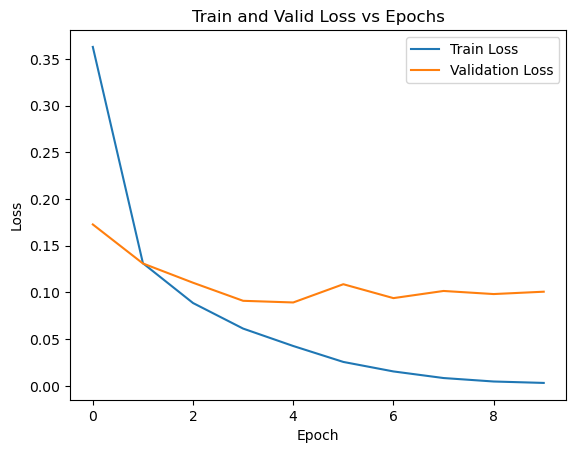

In [43]:
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['valid_losses'], label='Validation Loss')
plt.title('Train and Valid Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

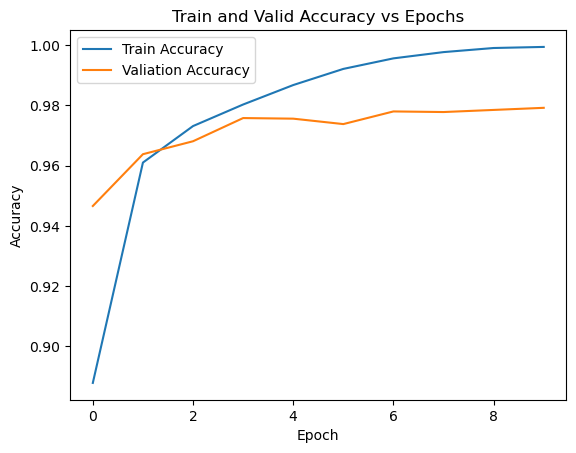

In [44]:
plt.plot(history['train_metrics'], label='Train Accuracy')
plt.plot(history['valid_metrics'], label='Valiation Accuracy')
plt.title('Train and Valid Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [45]:
print("test metric: ", evaluate_tm(model, test_loader, accuracy).item())

test metric:  0.9821000099182129


It does improve train-test-validation accuracies. With the training accuracy at 100% there is slight concern for a bit of overfitting at play, but with 98% test and validation accuracies, the results are promising.